## ============================================================
## Notebook: 03_churn_prediction.ipynb
## ============================================================

### ========================================
### 1. IMPORTS
### ========================================

In [7]:
# Core data manipulation
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,f1_score,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)

# Handling imbalanced data
from imblearn.over_sampling import SMOTE

# Model interpretation
import shap

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

import joblib

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


### ======================================
### 2. LOAD DATA
### ======================================

In [8]:
df = pd.read_csv('../data/processed/cleaned_transactions.csv', parse_dates=['invoicedate'])

print(f"Loaded {len(df):,} transactions")
print(f"Date range: {df['invoicedate'].min()} to {df['invoicedate'].max()}")
print(f"Unique customers: {df['customer_id'].nunique():,}")

Loaded 779,425 transactions
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Unique customers: 5,878


### =============================
### 3. DEFINE CHURN 
### =============================

In [9]:
# Use the last date in dataset as reference
reference_date = df['invoicedate'].max()
print(f"Reference date: {reference_date.date()}")

# Calculate last purchase date for each customer
last_purchase = df.groupby('customer_id')['invoicedate'].max().reset_index()
last_purchase.columns = ['customer_id', 'last_purchase_date']

# Calculate days since last purchase
last_purchase['days_since_last'] = (reference_date - last_purchase['last_purchase_date']).dt.days

# Define churn 
churn_threshold = 90
last_purchase['churned'] = (last_purchase['days_since_last'] > churn_threshold).astype(int)

print(f"\nChurn Analysis:")
print(f"   Active (purchased within {churn_threshold} days): {(last_purchase['churned'] == 0).sum():,}")
print(f"   Churned (no purchase in {churn_threshold}+ days): {(last_purchase['churned'] == 1).sum():,}")
print(f"   Churn rate: {last_purchase['churned'].mean()*100:.2f}%")

Reference date: 2011-12-09

Churn Analysis:
   Active (purchased within 90 days): 2,893
   Churned (no purchase in 90+ days): 2,985
   Churn rate: 50.78%


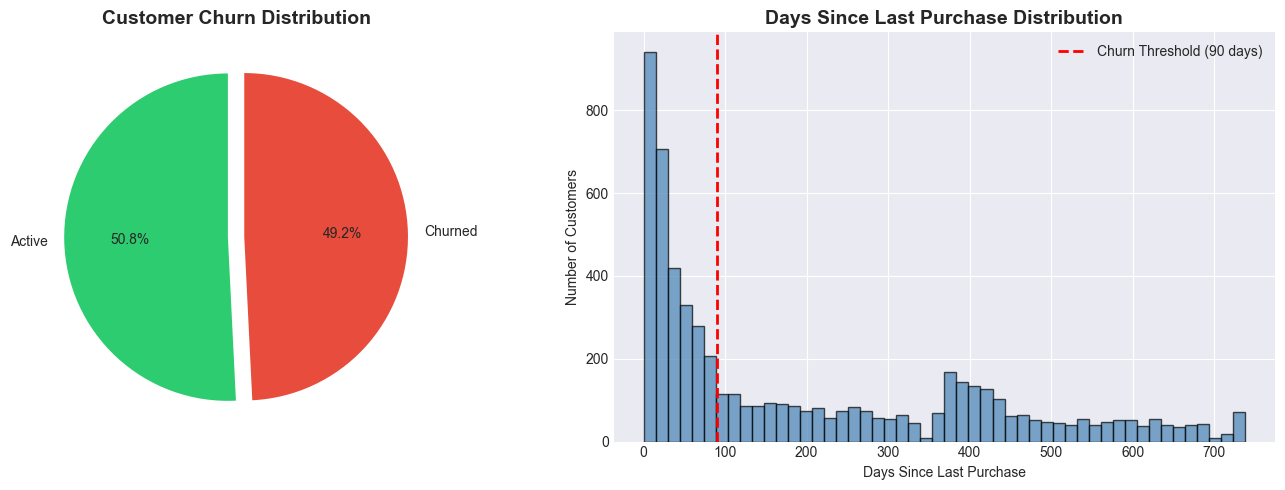

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
churn_counts = last_purchase['churned'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(churn_counts.values, labels=['Active', 'Churned'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')

# Days since last purchase histogram
axes[1].hist(last_purchase['days_since_last'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=churn_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Churn Threshold ({churn_threshold} days)')
axes[1].set_xlabel('Days Since Last Purchase')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Days Since Last Purchase Distribution', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### ===================================
### 4. FEATURE ENGINEERING 
### ===================================

In [18]:
print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Base features (available at any time)
customer_features = df.groupby('customer_id').agg({
    'invoice': [('total_orders', 'nunique')],
    'total_price': [
        ('total_spent', 'sum'),
        ('avg_order_value', 'mean'),
        ('max_order_value', 'max'),
        ('std_order_value', 'std')
    ],
    'quantity': [
        ('total_quantity', 'sum'),
        ('avg_quantity', 'mean')
    ],
    'price': [
        ('avg_item_price', 'mean'),
        ('max_item_price', 'max')
    ]
})

# Flatten column names
customer_features.columns = ['_'.join(col).strip() for col in customer_features.columns.values]
customer_features = customer_features.reset_index()

# Fill NaN values
customer_features['total_price_std_order_value'] = customer_features['total_price_std_order_value'].fillna(0)

print(f"✅ Base features created: {customer_features.shape[1] - 1} features")



FEATURE ENGINEERING
✅ Base features created: 9 features


### ============================
### 5. SAFE RECENCY WINDOWS 
### ============================

In [19]:
safe_windows = [30, 60]
reference = df['invoicedate'].max()

for window in safe_windows:
    window_start = reference - timedelta(days=window)
    recent_activity = df[df['invoicedate'] >= window_start].groupby('customer_id').size()
    recent_activity = recent_activity.rename(f'purchases_last_{window}_days')
    customer_features = customer_features.merge(
        recent_activity.reset_index(), on='customer_id', how='left'
    )
    customer_features[f'purchases_last_{window}_days'] = (
        customer_features[f'purchases_last_{window}_days'].fillna(0)
    )

print(f"✅ Added {len(safe_windows)} recency window features")


✅ Added 2 recency window features


### =========================================
### 6. CUSTOMER TENURE & PRODUCT DIVERSITY
### =========================================

In [20]:
# Customer tenure (based on first purchase date)
first_purchase = df.groupby('customer_id')['invoicedate'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_purchase_date']
customer_features = customer_features.merge(first_purchase, on='customer_id', how='left')

customer_features['customer_tenure_days'] = (
    reference - customer_features['first_purchase_date']
).dt.days
customer_features['customer_tenure_days'] = customer_features['customer_tenure_days'].fillna(0)


In [21]:
# Product diversity
product_diversity = df.groupby('customer_id')['stockcode'].nunique().reset_index()
product_diversity.columns = ['customer_id', 'unique_products']
customer_features = customer_features.merge(product_diversity, on='customer_id', how='left')
customer_features['unique_products'] = customer_features['unique_products'].fillna(0)

print(f"✅ Added tenure and diversity features")


✅ Added tenure and diversity features


### ======================================
### 7. PURCHASE CONSISTENCY (Regularity)
### ======================================

In [22]:
def calculate_regularity_safe(dates):
    """Calculate purchase regularity (lower std = more regular)"""
    if len(dates) < 3:
        return 0
    diffs = np.diff(sorted(dates)).astype('timedelta64[D]').astype(float)
    return np.std(diffs)


In [23]:
purchase_dates = df.groupby('customer_id')['invoicedate'].apply(list).reset_index()
purchase_dates['purchase_regularity_std'] = purchase_dates['invoicedate'].apply(calculate_regularity_safe)
customer_features = customer_features.merge(
    purchase_dates[['customer_id', 'purchase_regularity_std']], on='customer_id', how='left'
)
customer_features['purchase_regularity_std'] = customer_features['purchase_regularity_std'].fillna(0)

print(f"✅ Added purchase regularity features")

✅ Added purchase regularity features



### ============================
### 8. RATIO FEATURES 
### ============================

In [24]:
def safe_divide(a, b, default=0):
    if b == 0 or b is None:
        return default
    return a / b

In [25]:
customer_features['avg_items_per_order'] = customer_features.apply(
    lambda row: safe_divide(row['quantity_total_quantity'], row['invoice_total_orders']), axis=1
)

customer_features['spend_per_item'] = customer_features.apply(
    lambda row: safe_divide(row['total_price_total_spent'], row['quantity_total_quantity']), axis=1
)

customer_features['orders_per_month'] = customer_features.apply(
    lambda row: safe_divide(row['invoice_total_orders'], (row['customer_tenure_days'] / 30 + 0.001)), axis=1
)

customer_features['recency_ratio_30_60'] = customer_features.apply(
    lambda row: safe_divide(row['purchases_last_30_days'], (row['purchases_last_60_days'] + 1)), axis=1
)

print(f"✅ Added ratio features")

✅ Added ratio features


### ==================================================
### 9. CATEGORY PREFERENCES (Product categories)
### ==================================================

In [26]:
categories = {
    'home_decor': ['DECOR', 'FRAME', 'LIGHT', 'CANDLE', 'VASE', 'MIRROR'],
    'kitchen': ['MUG', 'CUP', 'PLATE', 'BOWL', 'JAR', 'STORAGE'],
    'garden': ['GARDEN', 'PLANT', 'FLOWER', 'OUTDOOR'],
    'toys': ['TOY', 'GAME', 'DOLL', 'PUZZLE'],
    'seasonal': ['CHRISTMAS', 'EASTER', 'HALLOWEEN', 'SEASONAL'],
    'art': ['ART', 'PAINTING', 'PHOTO', 'PRINT'],
    'furniture': ['CHAIR', 'TABLE', 'DESK', 'SHELF', 'RACK']
}

df['description_upper'] = df['description'].fillna('').str.upper()


In [27]:
for category, keywords in categories.items():
    mask = df['description_upper'].str.contains('|'.join(keywords), na=False)
    category_purchases = df[mask].groupby('customer_id').size()
    category_purchases = category_purchases.rename(f'{category}_purchases')
    customer_features = customer_features.merge(
        category_purchases.reset_index(), on='customer_id', how='left'
    )
    customer_features[f'{category}_purchases'] = customer_features[f'{category}_purchases'].fillna(0)

print(f"✅ Added {len(categories)} category features")

✅ Added 7 category features


### ================================
### 10. TEMPORAL PATTERNS
### ================================

In [28]:
df['hour'] = df['invoicedate'].dt.hour
df['day_of_week'] = df['invoicedate'].dt.dayofweek
df['month'] = df['invoicedate'].dt.month


In [29]:
# Peak hour purchases
peak_hours = df[df['hour'].between(10, 16)].groupby('customer_id').size()
peak_hours = peak_hours.rename('peak_hour_purchases')
customer_features = customer_features.merge(peak_hours.reset_index(), on='customer_id', how='left')
customer_features['peak_hour_purchases'] = customer_features['peak_hour_purchases'].fillna(0)

# Weekend purchases
weekend_purchases = df[df['day_of_week'].isin([5, 6])].groupby('customer_id').size()
weekend_purchases = weekend_purchases.rename('weekend_purchases')
customer_features = customer_features.merge(weekend_purchases.reset_index(), on='customer_id', how='left')
customer_features['weekend_purchases'] = customer_features['weekend_purchases'].fillna(0)

print(f"✅ Added temporal pattern features")

✅ Added temporal pattern features


### =====================================
### 11. DROP LEAKY AND DATE COLUMNS
### =====================================

In [30]:
# ============================================================
# REMOVE THESE LEAKY FEATURES
# ============================================================

leaky_features_to_remove = [
    'purchases_last_30_days',     
    'purchases_last_60_days',     
    'recency_ratio_30_60',        
]

print("Removing leaky features:")
for f in leaky_features_to_remove:
    if f in customer_features.columns:
        print(f"   ❌ {f}")
    else:
        print(f"   ✅ {f} not found (already removed)")

customer_features = customer_features.drop(columns=leaky_features_to_remove)
print(f"\n✅ Dropped leaky columns")
print(f"   Final feature count: {len([col for col in customer_features.columns if col != 'customer_id'])}")

Removing leaky features:
   ❌ purchases_last_30_days
   ❌ purchases_last_60_days
   ❌ recency_ratio_30_60

✅ Dropped leaky columns
   Final feature count: 25


In [33]:
print("=" * 60)
print("FINAL FEATURE CLEANUP")
print("=" * 60)

# 1. Remove ANY date columns
date_columns = [col for col in customer_features.columns if 'date' in col.lower() or 'time' in col.lower()]
print(f"\n📅 Removing date columns: {date_columns}")

# 2. Remove high-difference features that may be leaking
high_diff_features = [
    'customer_tenure_days',      # Can be calculated using future dates
    'avg_items_per_order',       # May use future data
    'spend_per_item',            # May use future data  
    'orders_per_month',          # Derived from tenure
    'purchase_regularity_std',   # Uses future dates
]

# 3. Remove category features that are too specific (causing overfitting)
category_features = [col for col in customer_features.columns if any(cat in col for cat in 
    ['home_decor', 'kitchen', 'garden', 'toys', 'seasonal', 'art', 'furniture'])]

print(f"\n🏷️ Removing category features: {len(category_features)} features")

# Combine all features to remove
features_to_remove_final = list(set(date_columns + high_diff_features + category_features))
features_to_remove_final = [f for f in features_to_remove_final if f in customer_features.columns]

print(f"\n🚫 Total features to remove: {len(features_to_remove_final)}")

# Remove them
customer_features_final = customer_features.drop(columns=features_to_remove_final)

print(f"\n📊 Original features: {customer_features.shape[1]}")
print(f"📊 Final features: {customer_features_final.shape[1]}")
print(f"\n✅ Final feature list:")
for col in customer_features_final.columns:
    print(f"   - {col}")
    
    

FINAL FEATURE CLEANUP

📅 Removing date columns: ['first_purchase_date']

🏷️ Removing category features: 7 features

🚫 Total features to remove: 13

📊 Original features: 26
📊 Final features: 13

✅ Final feature list:
   - customer_id
   - invoice_total_orders
   - total_price_total_spent
   - total_price_avg_order_value
   - total_price_max_order_value
   - total_price_std_order_value
   - quantity_total_quantity
   - quantity_avg_quantity
   - price_avg_item_price
   - price_max_item_price
   - unique_products
   - peak_hour_purchases
   - weekend_purchases


### ==========================================
### 12. MERGE TARGET VARIABLE & CLEAN DATA
### ==========================================

In [34]:
# Merge churn labels
df_model = customer_features_final.merge(last_purchase[['customer_id', 'churned']], on='customer_id', how='inner')

# Remove customer_id for modeling
df_model = df_model.drop('customer_id', axis=1)

# Clean infinite and NaN values
print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)

print(f"Before cleaning:")
print(f"   Shape: {df_model.shape}")
print(f"   Infinities: {np.isinf(df_model).any().any()}")
print(f"   NaNs: {df_model.isna().any().any()}")

# Replace infinite with NaN
df_model = df_model.replace([np.inf, -np.inf], np.nan)



DATA CLEANING
Before cleaning:
   Shape: (5878, 13)
   Infinities: False
   NaNs: False


In [35]:
# Fill all NaN with 0
df_model = df_model.fillna(0)

# Ensure all numeric
df_model = df_model.astype(int)

print(f"\nAfter cleaning:")
print(f"   Shape: {df_model.shape}")
print(f"   Infinities: {np.isinf(df_model).any().any()}")
print(f"   NaNs: {df_model.isna().any().any()}")



After cleaning:
   Shape: (5878, 13)
   Infinities: False
   NaNs: False


### ========================================
### 13. PREPARE FEATURES AND TARGET
### ========================================

In [36]:
feature_cols = [col for col in df_model.columns if col != 'churned']
X = df_model[feature_cols]
y = df_model['churned']

print(f"\n📊 Final dataset:")
print(f"   Features: {X.shape[1]}")
print(f"   Customers: {X.shape[0]:,}")
print(f"   Churn rate: {y.mean()*100:.2f}%")

# Check feature correlations
print(f"\n🔍 Quick leakage check:")
high_corr = []
for col in X.columns:
    corr = abs(X[col].corr(y))
    if corr > 0.90:
        high_corr.append((col, corr))

if high_corr:
    print(f"   ⚠️ High correlation detected (possible leakage):")
    for col, corr in high_corr[:5]:
        print(f"      - {col}: {corr:.3f}")
else:
    print(f"   ✅ No suspicious high correlations detected")


📊 Final dataset:
   Features: 12
   Customers: 5,878
   Churn rate: 50.78%

🔍 Quick leakage check:
   ✅ No suspicious high correlations detected


### ============================
### 14. TRAIN-TEST SPLIT
### ============================

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [38]:
print(f"\n📊 Train-Test Split:")
print(f"   Training set: {X_train.shape[0]:,} customers ({y_train.mean()*100:.2f}% churn)")
print(f"   Test set: {X_test.shape[0]:,} customers ({y_test.mean()*100:.2f}% churn)")


📊 Train-Test Split:
   Training set: 4,702 customers (50.79% churn)
   Test set: 1,176 customers (50.77% churn)


### ===============================
### 15. SCALE FEATURES
### ===============================

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [40]:
# Convert back to DataFrame for interpretation
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

print(f"\n✅ Scaling complete:")
print(f"   X_train_scaled shape: {X_train_scaled.shape}")
print(f"   X_test_scaled shape: {X_test_scaled.shape}")

# Verify scaling
print(f"\n📊 Scaling verification:")
for i, col in enumerate(feature_cols[:3]):
    print(f"   {col}: mean={X_train_scaled[:, i].mean():.6f}, std={X_train_scaled[:, i].std():.6f}")


✅ Scaling complete:
   X_train_scaled shape: (4702, 12)
   X_test_scaled shape: (1176, 12)

📊 Scaling verification:
   invoice_total_orders: mean=0.000000, std=1.000000
   total_price_total_spent: mean=0.000000, std=1.000000
   total_price_avg_order_value: mean=-0.000000, std=1.000000


### ============================================
### 16. HANDLE CLASS IMBALANCE WITH SMOTE
### ============================================

In [41]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [42]:
print(f"\n📊 SMOTE Resampling:")
print(f"   Original training size: {X_train_scaled.shape[0]:,}")
print(f"   Resampled training size: {X_train_resampled.shape[0]:,}")
print(f"   New churn rate: {y_train_resampled.mean()*100:.2f}%")


📊 SMOTE Resampling:
   Original training size: 4,702
   Resampled training size: 4,776
   New churn rate: 50.00%


### ============================
### 17. TRAIN MODELS
### ============================

In [43]:
print("\n" + "=" * 60)
print("MODEL TRAINING")
print("=" * 60)

# Initialize models with conservative parameters to prevent overfitting
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, 
        max_depth=5, 
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, 
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        random_state=42, 
        max_iter=1000,
        C=1.0,
        class_weight='balanced'
    )
}

# Train and evaluate each model
results = []
trained_models = {}

for name, model in models.items():
    print(f"\n📊 Training {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    trained_models[name] = model
    
    # Predictions
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_pred_proba > 0.5).astype(int)
    
    # Metrics
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
        'Avg Precision': average_precision_score(y_test, y_pred_proba),
        'F1 Score': f1_score(y_test, y_pred)
    })
    
    print(f"   ROC-AUC: {results[-1]['ROC-AUC']:.4f}")
    print(f"   F1 Score: {results[-1]['F1 Score']:.4f}")


MODEL TRAINING

📊 Training Random Forest...
   ROC-AUC: 0.7810
   F1 Score: 0.7210

📊 Training Gradient Boosting...
   ROC-AUC: 0.7809
   F1 Score: 0.7192

📊 Training Logistic Regression...
   ROC-AUC: 0.7727
   F1 Score: 0.7333


### ==========================
### 18. MODEL COMPARISON
### ==========================

In [44]:
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results_df.to_string(index=False))

# Select best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\n✅ Best model: {best_model_name}")
print(f"   ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")

# Validate metrics are realistic
if results_df.iloc[0]['ROC-AUC'] > 0.95:
    print("\n⚠️ WARNING: ROC-AUC > 0.95 detected!")
    print("   This may indicate data leakage. Review features for:")
    print("   - Date columns that shouldn't be available")
    print("   - Features that directly correlate with churn definition")
    print("   - Future information leaking into training data")


MODEL COMPARISON
              Model  ROC-AUC  Avg Precision  F1 Score
      Random Forest 0.780980       0.765276  0.721023
  Gradient Boosting 0.780925       0.765408  0.719228
Logistic Regression 0.772747       0.750759  0.733333

✅ Best model: Random Forest
   ROC-AUC: 0.7810


### =====================================
### 19. FEATURE IMPORTANCE (Best Model)
### =====================================


TOP 20 FEATURE IMPORTANCES
                    feature  importance
       invoice_total_orders    0.256583
    quantity_total_quantity    0.204195
    total_price_total_spent    0.162642
        peak_hour_purchases    0.159265
            unique_products    0.103322
total_price_max_order_value    0.021758
total_price_std_order_value    0.020997
          weekend_purchases    0.018294
total_price_avg_order_value    0.016364
      quantity_avg_quantity    0.015929
       price_max_item_price    0.010675
       price_avg_item_price    0.009975


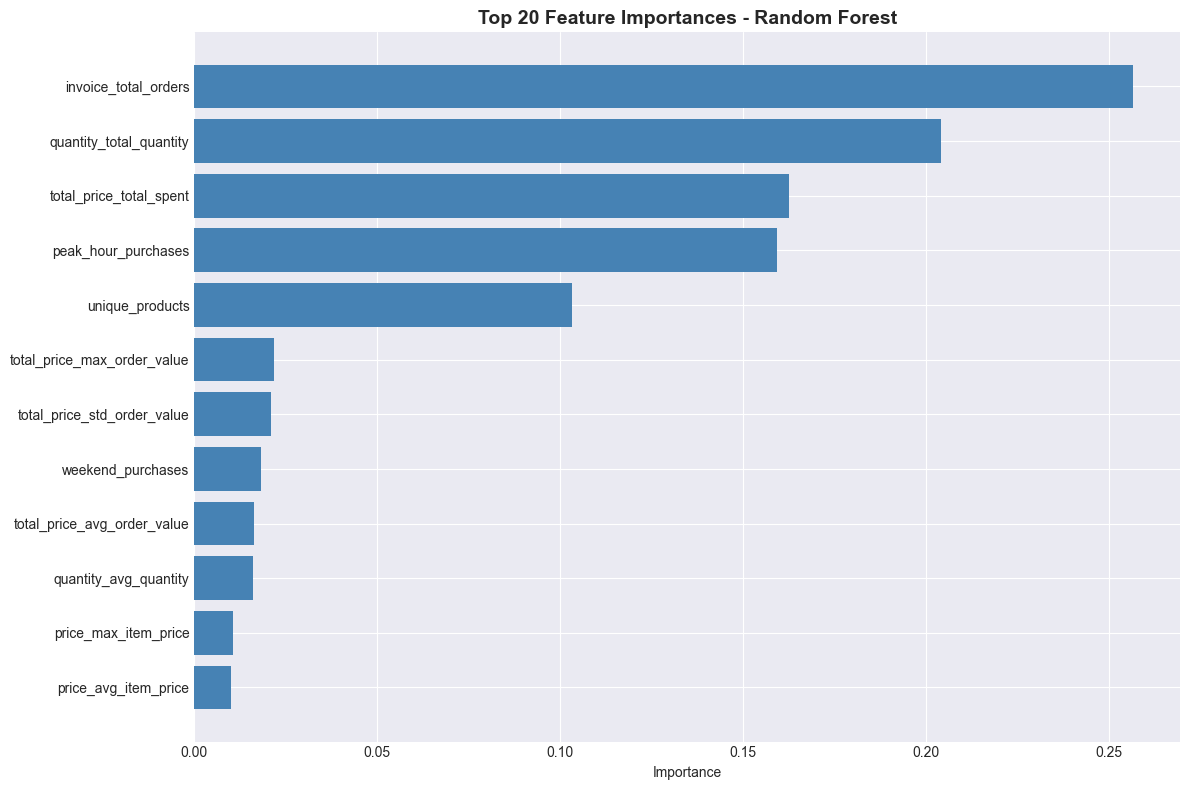


✅ Feature importance chart saved to '../reports/churn_feature_importance.png'


In [45]:
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(20)
    
    print("\n" + "=" * 60)
    print("TOP 20 FEATURE IMPORTANCES")
    print("=" * 60)
    print(feature_importance.to_string(index=False))
    
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'Top 20 Feature Importances - {best_model_name}', fontweight='bold', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../reports/churn_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Feature importance chart saved to '../reports/churn_feature_importance.png'")
else:
    # For Logistic Regression, use coefficients
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': abs(best_model.coef_[0])
    }).sort_values('importance', ascending=False).head(20)
    
    print("\n" + "=" * 60)
    print("TOP 20 FEATURE COEFFICIENTS")
    print("=" * 60)
    print(feature_importance.to_string(index=False))

### =====================================
### 20. CONFUSION MATRIX & ROC CURVE
### =====================================

In [46]:
# Get predictions from best model
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

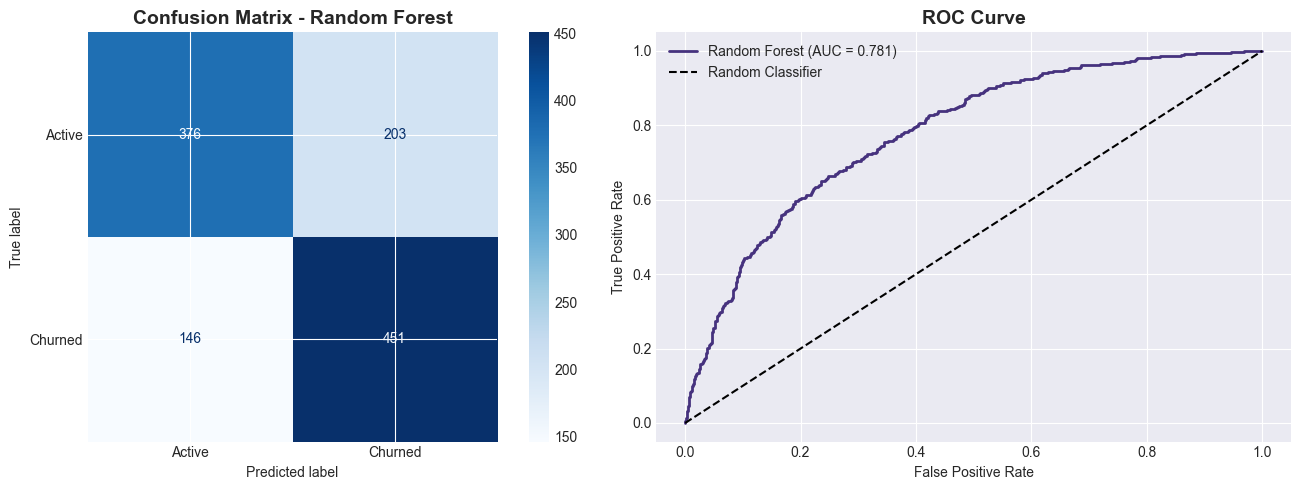


✅ Confusion matrix and ROC curve saved to '../reports/churn_confusion_roc.png'

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Active       0.72      0.65      0.68       579
     Churned       0.69      0.76      0.72       597

    accuracy                           0.70      1176
   macro avg       0.70      0.70      0.70      1176
weighted avg       0.70      0.70      0.70      1176



In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_score:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/churn_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrix and ROC curve saved to '../reports/churn_confusion_roc.png'")
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

### ===========================================
### 21. SHAP ANALYSIS (Model Interpretability)
### ===========================================


SHAP ANALYSIS - Model Interpretability


<Figure size 1200x800 with 0 Axes>

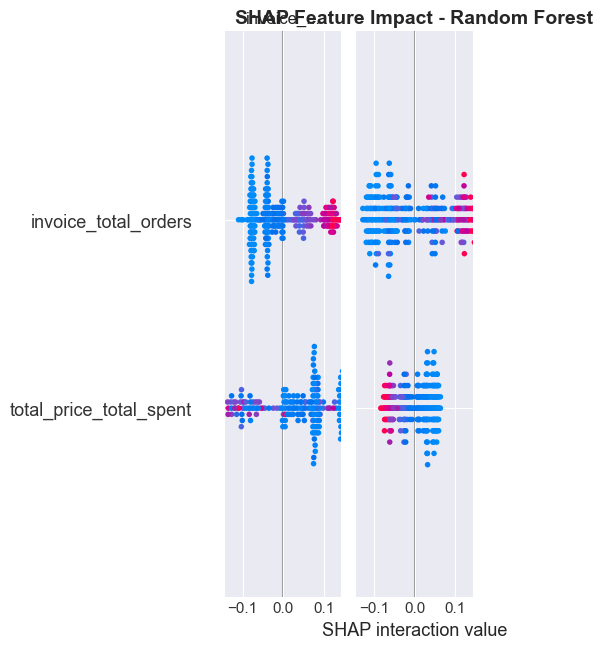

✅ SHAP summary saved to '../reports/churn_shap_summary.png'


In [48]:
print("\n" + "=" * 60)
print("SHAP ANALYSIS - Model Interpretability")
print("=" * 60)

try:
    # Use a sample for SHAP
    X_sample = X_test_scaled_df.sample(n=min(300, len(X_test_scaled_df)), random_state=42)
    
    if best_model_name in ['Random Forest', 'Gradient Boosting']:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_sample)
        
        # For binary classification, use class 1 (churned)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, show=False)
        plt.title(f'SHAP Feature Impact - {best_model_name}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('../reports/churn_shap_summary.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✅ SHAP summary saved to '../reports/churn_shap_summary.png'")
    else:
        print("⚠️ SHAP analysis skipped - best model is not tree-based")
        
except Exception as e:
    print(f"⚠️ SHAP analysis skipped: {e}")

### ========================================
### 22. PREDICT HIGH-RISK ACTIVE CUSTOMERS
### ========================================

In [49]:
print("\n" + "=" * 60)
print("PREDICTING HIGH-RISK ACTIVE CUSTOMERS")
print("=" * 60)

# Get ALL customer features (original, before train/test split)
X_full = customer_features[feature_cols].copy()

# Clean
X_full = X_full.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

# Scale using the same scaler
X_full_scaled = scaler.transform(X_full)

# Predict probabilities
proba_predictions = best_model.predict_proba(X_full_scaled)[:, 1]

# Create risk dataframe
risk_df = pd.DataFrame({
    'customer_id': customer_features['customer_id'],
    'churn_risk_score': proba_predictions,
    'predicted_churn': (proba_predictions > 0.5).astype(int)
})

# Merge with actual data
risk_df = risk_df.merge(last_purchase[['customer_id', 'days_since_last', 'churned']], on='customer_id', how='left')
risk_df = risk_df.merge(
    customer_features[['customer_id', 'total_price_total_spent', 'invoice_total_orders']], 
    on='customer_id', 
    how='left'
)

print(f"\n📊 Customer Status Breakdown:")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Total customers:     {len(risk_df):>6,} │")
print(f"   │ Already churned:     {(risk_df['churned'] == 1).sum():>6,} │")
print(f"   │ Active customers:    {(risk_df['churned'] == 0).sum():>6,} │")
print(f"   └─────────────────────────────────────────┘")

# Focus ONLY on active customers
active_customers = risk_df[risk_df['churned'] == 0].copy()

if len(active_customers) > 0:
    # Get high-risk among active customers (top 20%)
    threshold_80 = active_customers['churn_risk_score'].quantile(0.8)
    high_risk_active = active_customers[active_customers['churn_risk_score'] >= threshold_80].sort_values('churn_risk_score', ascending=False)
    
    print(f"\n🎯 HIGH-RISK ACTIVE CUSTOMERS (Top 20% of active):")
    print(f"   ┌─────────────────────────────────────────────────────┐")
    print(f"   │ Count:                    {len(high_risk_active):>6} │")
    print(f"   │ Risk score threshold:     {threshold_80:.3f} │")
    print(f"   │ Revenue at risk:          ${high_risk_active['total_price_total_spent'].sum():>10,.2f} │")
    print(f"   │ Avg risk score:           {high_risk_active['churn_risk_score'].mean():.3f} │")
    print(f"   └─────────────────────────────────────────────────────┘")
    
    print(f"\n🏆 TOP 10 HIGH-RISK ACTIVE CUSTOMERS:")
    print(high_risk_active[['customer_id', 'churn_risk_score', 'days_since_last', 
                            'total_price_total_spent', 'invoice_total_orders']].head(10).to_string(index=False))
    
    # Save results
    high_risk_active.to_csv('../data/processed/high_risk_active_customers.csv', index=False)
    print(f"\n✅ Saved high-risk ACTIVE customers to '../data/processed/high_risk_active_customers.csv'")
else:
    print("\n⚠️ No active customers found!")


PREDICTING HIGH-RISK ACTIVE CUSTOMERS

📊 Customer Status Breakdown:
   ┌─────────────────────────────────────────┐
   │ Total customers:      5,878 │
   │ Already churned:      2,985 │
   │ Active customers:     2,893 │
   └─────────────────────────────────────────┘

🎯 HIGH-RISK ACTIVE CUSTOMERS (Top 20% of active):
   ┌─────────────────────────────────────────────────────┐
   │ Count:                       579 │
   │ Risk score threshold:     0.612 │
   │ Revenue at risk:          $213,075.61 │
   │ Avg risk score:           0.699 │
   └─────────────────────────────────────────────────────┘

🏆 TOP 10 HIGH-RISK ACTIVE CUSTOMERS:
 customer_id  churn_risk_score  days_since_last  total_price_total_spent  invoice_total_orders
       18019          0.898050               51                    38.45                     1
       14792          0.865481               63                     6.20                     1
       14974          0.848603               36                    89.94     

### ==================================
### 23. BUSINESS RECOMMENDATIONS
### ==================================

In [50]:
print("\n" + "=" * 60)
print("BUSINESS RECOMMENDATIONS")
print("=" * 60)

if len(active_customers) > 0:
    high_risk_count = len(high_risk_active)
    revenue_at_risk = high_risk_active['total_price_total_spent'].sum()
    estimated_recovery = revenue_at_risk * 0.20
    
    print(f"\n📊 MODEL INSIGHTS:")
    print(f"   • {high_risk_count} active customers identified as high-risk")
    print(f"   • These customers represent ${revenue_at_risk:,.2f} in potential revenue at risk")
    print(f"   • Average risk score: {high_risk_active['churn_risk_score'].mean():.3f}")
    
    print(f"\n🎯 IMMEDIATE ACTIONS:")
    print(f"   1. Send personalized win-back emails to top 100 highest-risk customers")
    print(f"   2. Offer 15-20% discount codes valid for 14 days")
    print(f"   3. Flag high-value at-risk customers for priority support")
    
    print(f"\n💰 FINANCIAL IMPACT:")
    print(f"   • Total revenue at risk: ${revenue_at_risk:,.2f}")
    print(f"   • Estimated recoverable revenue (20%): ${estimated_recovery:,.2f}")
    print(f"   • Maximum campaign budget for positive ROI: ${estimated_recovery:,.2f}")


BUSINESS RECOMMENDATIONS

📊 MODEL INSIGHTS:
   • 579 active customers identified as high-risk
   • These customers represent $213,075.61 in potential revenue at risk
   • Average risk score: 0.699

🎯 IMMEDIATE ACTIONS:
   1. Send personalized win-back emails to top 100 highest-risk customers
   2. Offer 15-20% discount codes valid for 14 days
   3. Flag high-value at-risk customers for priority support

💰 FINANCIAL IMPACT:
   • Total revenue at risk: $213,075.61
   • Estimated recoverable revenue (20%): $42,615.12
   • Maximum campaign budget for positive ROI: $42,615.12


### ====================================
### 24. SAVE MODEL FOR PRODUCTION
### ===================================

In [51]:
# Save best model and scaler
joblib.dump(best_model, '../models/churn_prediction_model.pkl')
joblib.dump(scaler, '../models/feature_scaler.pkl')

# Save feature list
feature_list = pd.DataFrame({'feature': feature_cols})
feature_list.to_csv('../models/feature_list.csv', index=False)

print("\n✅ Model artifacts saved:")
print(f"   - Model: ../models/churn_prediction_model.pkl")
print(f"   - Scaler: ../models/feature_scaler.pkl")
print(f"   - Features: ../models/feature_list.csv")

print("\n" + "=" * 60)
print("🎉 CHURN PREDICTION MODEL COMPLETE!")
print("=" * 60)


✅ Model artifacts saved:
   - Model: ../models/churn_prediction_model.pkl
   - Scaler: ../models/feature_scaler.pkl
   - Features: ../models/feature_list.csv

🎉 CHURN PREDICTION MODEL COMPLETE!
